In [1]:
%pip install yfinance matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import yfinance as yf
import matplotlib.pyplot as plt

stock = yf.Ticker("000660.KS")
df = stock.history(period="1y", auto_adjust=False)

df.tail()

,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits
Date,,,,,,,,
2026-09-17 00:00:00+09:00,1770000.0,1785000.0,1735000.0,1745000.0,1745000.0,2803398,0.0,0.0
2026-09-18 00:00:00+09:00,1810000.0,1857000.0,1805000.0,1857000.0,1857000.0,4764077,0.0,0.0
2026-09-21 00:00:00+09:00,1872000.0,1888000.0,1847000.0,1868000.0,1868000.0,2755380,0.0,0.0
2026-09-22 00:00:00+09:00,1909000.0,1935000.0,1832000.0,1840000.0,1840000.0,3271767,0.0,0.0
2026-09-23 00:00:00+09:00,1899000.0,1900000.0,1836000.0,1862000.0,1862000.0,2947714,0.0,0.0


In [3]:
latest_price = df["Close"].iloc[-1]

print(f"SK하이닉스 최근 종가: {latest_price:,.0f}원")


SK하이닉스 최근 종가: 1,862,000원


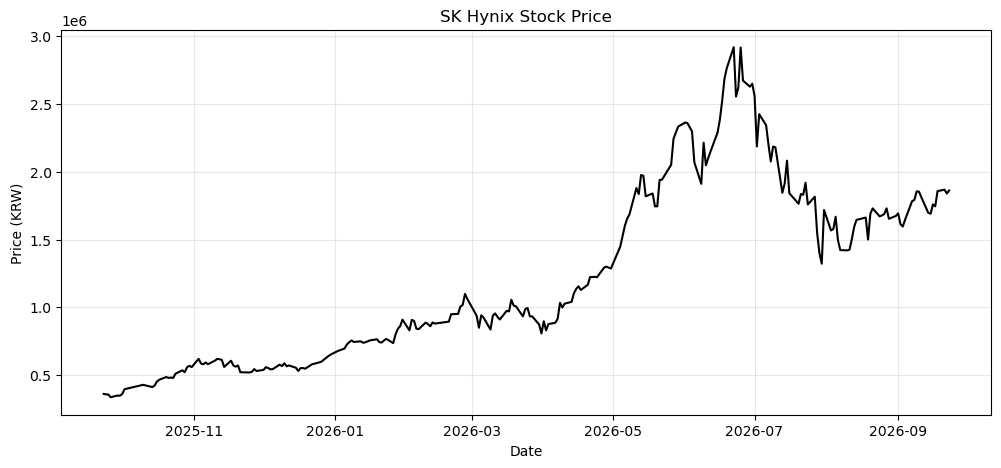

In [4]:
plt.figure(figsize=(12, 5))
plt.plot(df.index, df["Close"], color="black")
plt.title("SK Hynix Stock Price")
plt.xlabel("Date")
plt.ylabel("Price (KRW)")
plt.grid(alpha=0.3)
plt.show()

In [5]:
# 이동평균선과 수익률 계산
df["MA20"] = df["Close"].rolling(20).mean()
df["MA60"] = df["Close"].rolling(60).mean()
df["Daily_Return"] = df["Close"].pct_change() * 100

latest = df.iloc[-1]

print(f"최근 종가: {latest['Close']:,.0f}원")
print(f"20일 평균: {latest['MA20']:,.0f}원")
print(f"60일 평균: {latest['MA60']:,.0f}원")
print(f"오늘 수익률: {latest['Daily_Return']:.2f}%")

if latest["Close"] > latest["MA20"]:
    print("단기 추세: 20일선 위에 있음 🟢")
else:
    print("단기 추세: 20일선 아래에 있음 🔴")

최근 종가: 1,862,000원
20일 평균: 1,751,050원
60일 평균: 1,789,367원
오늘 수익률: 1.20%
단기 추세: 20일선 위에 있음 🟢


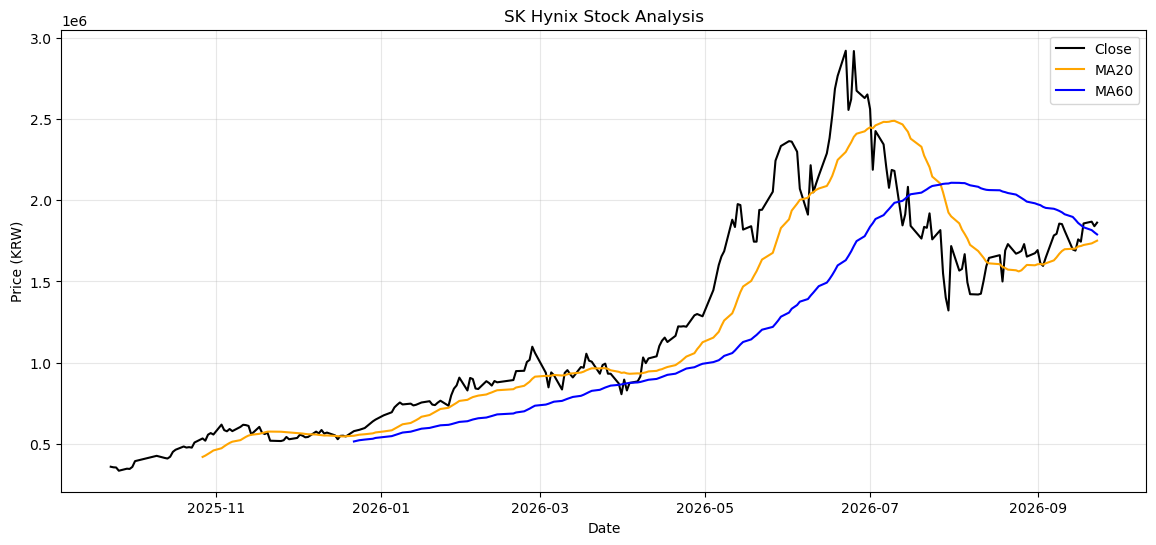

In [6]:
plt.figure(figsize=(14, 6))

plt.plot(df.index, df["Close"], label="Close", color="black")
plt.plot(df.index, df["MA20"], label="MA20", color="orange")
plt.plot(df.index, df["MA60"], label="MA60", color="blue")

plt.title("SK Hynix Stock Analysis")
plt.xlabel("Date")
plt.ylabel("Price (KRW)")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [7]:
latest = df.iloc[-1]
one_year_ago = df.iloc[0]

year_return = (
    (latest["Close"] / one_year_ago["Close"]) - 1
) * 100

print(f"기준 날짜: {df.index[-1].date()}")
print(f"최근 종가: {latest['Close']:,.0f}원")
print(f"20일 이동평균: {latest['MA20']:,.0f}원")
print(f"60일 이동평균: {latest['MA60']:,.0f}원")
print(f"최근 1년 수익률: {year_return:.2f}%")

기준 날짜: 2026-09-23
최근 종가: 1,862,000원
20일 이동평균: 1,751,050원
60일 이동평균: 1,789,367원
최근 1년 수익률: 415.79%


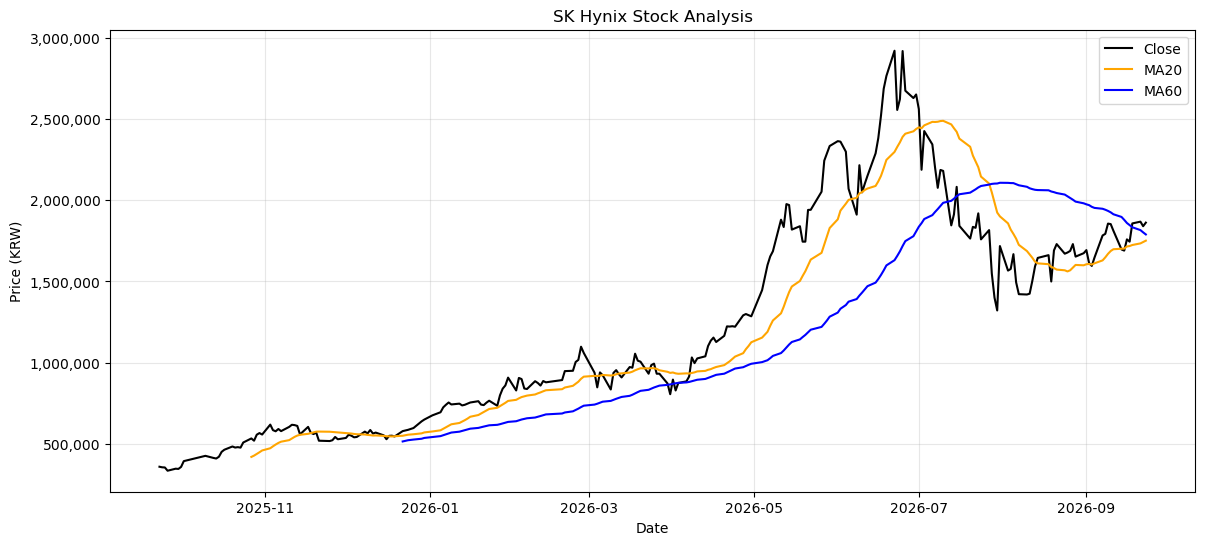

In [8]:
from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(14, 6))
plt.plot(df.index, df["Close"], label="Close", color="black")
plt.plot(df.index, df["MA20"], label="MA20", color="orange")
plt.plot(df.index, df["MA60"], label="MA60", color="blue")

plt.title("SK Hynix Stock Analysis")
plt.xlabel("Date")
plt.ylabel("Price (KRW)")
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x:,.0f}")
)

plt.grid(alpha=0.3)
plt.legend()
plt.show()


In [9]:
# 거래량 평균 계산
df["Volume_MA20"] = df["Volume"].rolling(20).mean()

latest = df.iloc[-1]

price = latest["Close"]
ma20 = latest["MA20"]
ma60 = latest["MA60"]
volume = latest["Volume"]
volume_ma20 = latest["Volume_MA20"]

# 추세 판정
if price > ma20 > ma60:
    trend = "강한 상승 추세"
elif price > ma20 and price > ma60:
    trend = "상승 시도"
elif price < ma20 < ma60:
    trend = "하락 추세"
else:
    trend = "방향성이 불분명한 구간"

# 거래량 판정
volume_ratio = volume / volume_ma20

if volume_ratio >= 1.5:
    volume_status = "평균보다 거래량이 크게 증가함"
elif volume_ratio >= 1:
    volume_status = "평균보다 거래량이 조금 많음"
else:
    volume_status = "평균보다 거래량이 적음"

print("===== SK하이닉스 자동 분석 =====")
print(f"최근 종가: {price:,.0f}원")
print(f"20일 이동평균: {ma20:,.0f}원")
print(f"60일 이동평균: {ma60:,.0f}원")
print(f"기술적 상태: {trend}")
print(f"거래량 상태: {volume_status}")
print(f"20일 평균 대비 거래량: {volume_ratio:.2f}배")

===== SK하이닉스 자동 분석 =====
최근 종가: 1,862,000원
20일 이동평균: 1,751,050원
60일 이동평균: 1,789,367원
기술적 상태: 상승 시도
거래량 상태: 평균보다 거래량이 적음
20일 평균 대비 거래량: 0.89배


In [10]:
import yfinance as yf
import matplotlib.pyplot as plt


def analyze_stock(ticker, period="1y"):
    # 1. 주가 데이터 불러오기
    stock = yf.Ticker(ticker)
    df = stock.history(
        period=period,
        auto_adjust=False
    )

    # 데이터가 없을 때 프로그램 중단
    if df.empty:
        print("주가 데이터를 찾지 못했습니다.")
        return

    # 2. 분석 지표 계산
    df["MA20"] = df["Close"].rolling(20).mean()
    df["MA60"] = df["Close"].rolling(60).mean()
    df["Daily_Return"] = df["Close"].pct_change() * 100
    df["Volume_MA20"] = df["Volume"].rolling(20).mean()

    # 3. 가장 최근 데이터 선택
    latest = df.iloc[-1]

    price = latest["Close"]
    ma20 = latest["MA20"]
    ma60 = latest["MA60"]
    daily_return = latest["Daily_Return"]
    volume_ratio = latest["Volume"] / latest["Volume_MA20"]

    # 4. 추세 판정
    if price > ma20 > ma60:
        trend = "강한 상승 추세"

    elif price > ma20 and price > ma60:
        trend = "상승 시도"

    elif price < ma20 < ma60:
        trend = "하락 추세"

    else:
        trend = "방향성이 불분명한 구간"

    # 5. 분석 결과 출력
    print("===== 종목 자동 분석 =====")
    print(f"종목코드: {ticker}")
    print(f"기준 날짜: {df.index[-1].date()}")
    print(f"최근 종가: {price:,.0f}원")
    print(f"오늘 수익률: {daily_return:.2f}%")
    print(f"20일 이동평균: {ma20:,.0f}원")
    print(f"60일 이동평균: {ma60:,.0f}원")
    print(f"기술적 상태: {trend}")
    print(f"평균 대비 거래량: {volume_ratio:.2f}배")

    # 6. 차트 출력
    plt.figure(figsize=(14, 6))

    plt.plot(
        df.index,
        df["Close"],
        label="Close",
        color="black"
    )

    plt.plot(
        df.index,
        df["MA20"],
        label="MA20",
        color="orange"
    )

    plt.plot(
        df.index,
        df["MA60"],
        label="MA60",
        color="blue"
    )

    plt.title(f"{ticker} Stock Analysis")
    plt.xlabel("Date")
    plt.ylabel("Price")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

    # 다른 분석에서도 사용할 수 있도록 데이터 반환
    return df
    

===== 종목 자동 분석 =====
종목코드: 000660.KS
기준 날짜: 2026-09-23
최근 종가: 1,862,000원
오늘 수익률: 1.20%
20일 이동평균: 1,751,050원
60일 이동평균: 1,789,367원
기술적 상태: 상승 시도
평균 대비 거래량: 0.89배


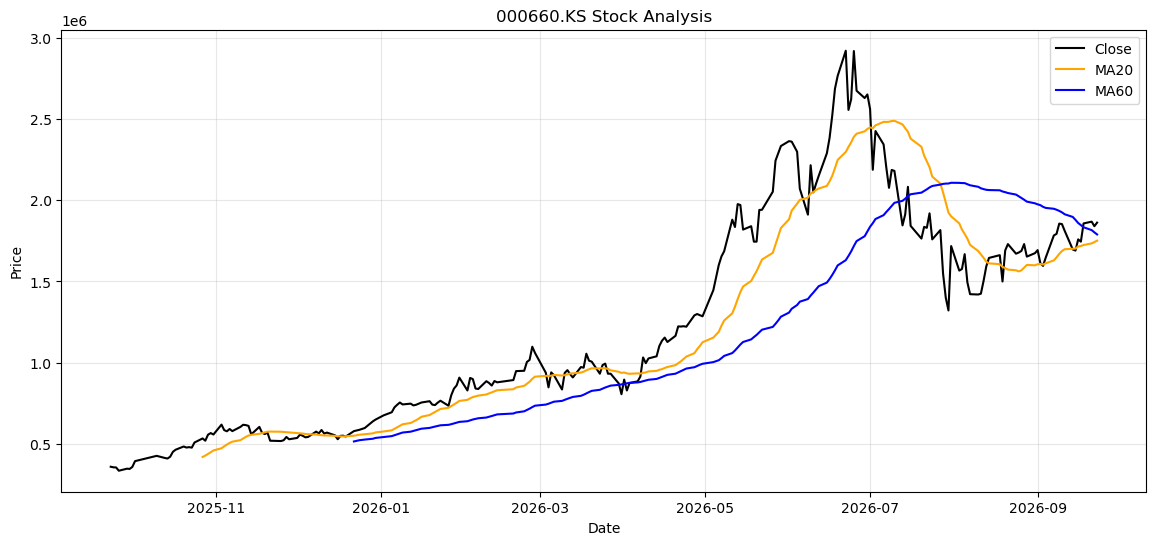

In [11]:
hynix_df = analyze_stock("000660.KS", "1y")

===== 종목 자동 분석 =====
종목코드: 000660.KS
기준 날짜: 2026-09-23
최근 종가: 1,862,000원
오늘 수익률: 1.20%
20일 이동평균: 1,751,050원
60일 이동평균: 1,789,367원
기술적 상태: 상승 시도
평균 대비 거래량: 0.89배


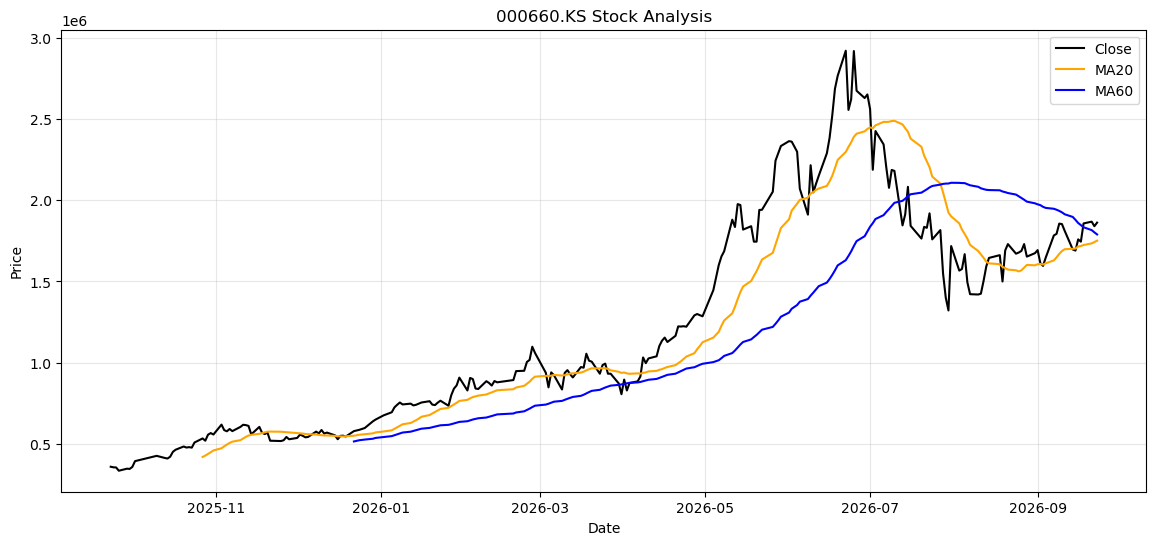

In [12]:
hynix_df = analyze_stock("000660.KS", "1y")


===== 종목 자동 분석 =====
종목코드: 005930.KS
기준 날짜: 2026-09-23
최근 종가: 285,500원
오늘 수익률: 3.25%
20일 이동평균: 261,900원
60일 이동평균: 262,033원
기술적 상태: 상승 시도
평균 대비 거래량: 1.25배


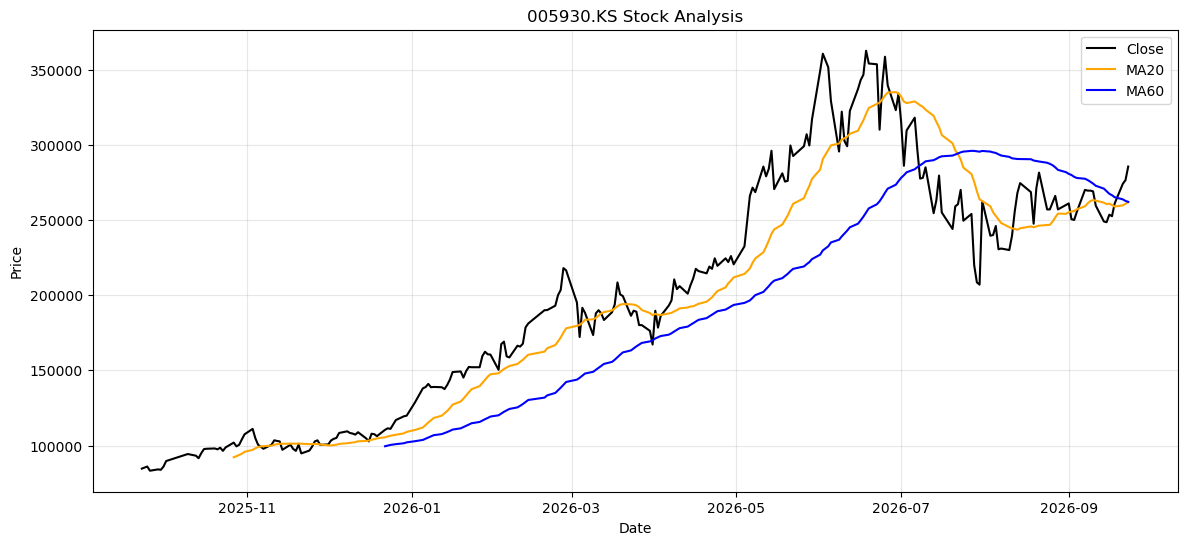

In [13]:
samsung_df = analyze_stock("005930.KS", "1y")

In [14]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

In [15]:
stock = yf.Ticker("000660.KS")

df = stock.history(
    period="1y",
    auto_adjust=False
)

df.tail()


,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits
Date,,,,,,,,
2026-09-17 00:00:00+09:00,1770000.0,1785000.0,1735000.0,1745000.0,1745000.0,2803398,0.0,0.0
2026-09-18 00:00:00+09:00,1810000.0,1857000.0,1805000.0,1857000.0,1857000.0,4764077,0.0,0.0
2026-09-21 00:00:00+09:00,1872000.0,1888000.0,1847000.0,1868000.0,1868000.0,2755380,0.0,0.0
2026-09-22 00:00:00+09:00,1909000.0,1935000.0,1832000.0,1840000.0,1840000.0,3271767,0.0,0.0
2026-09-23 00:00:00+09:00,1899000.0,1900000.0,1836000.0,1862000.0,1862000.0,2947714,0.0,0.0


In [16]:
# RSI 계산
period = 14

price_change = df["Close"].diff()

gain = price_change.clip(lower=0)
loss = -price_change.clip(upper=0)

average_gain = gain.rolling(period).mean()
average_loss = loss.rolling(period).mean()

rs = average_gain / average_loss

df["RSI"] = 100 - (100 / (1 + rs))

df[["Close", "RSI"]].tail()

,Close,RSI
Date,,
2026-09-17 00:00:00+09:00,1745000.0,57.120743
2026-09-18 00:00:00+09:00,1857000.0,62.415197
2026-09-21 00:00:00+09:00,1868000.0,62.002743
2026-09-22 00:00:00+09:00,1840000.0,66.765140
2026-09-23 00:00:00+09:00,1862000.0,69.501466


In [17]:
latest_rsi = df["RSI"].iloc[-1]

print(f"현재 RSI: {latest_rsi:.2f}")

if latest_rsi >= 70:
    print("RSI 상태: 과열 가능성")

elif latest_rsi <= 30:
    print("RSI 상태: 과매도 가능성")

elif latest_rsi >= 50:
    print("RSI 상태: 상승 힘이 상대적으로 강함")

else:
    print("RSI 상태: 하락 힘이 상대적으로 강함")
    

현재 RSI: 69.50
RSI 상태: 상승 힘이 상대적으로 강함


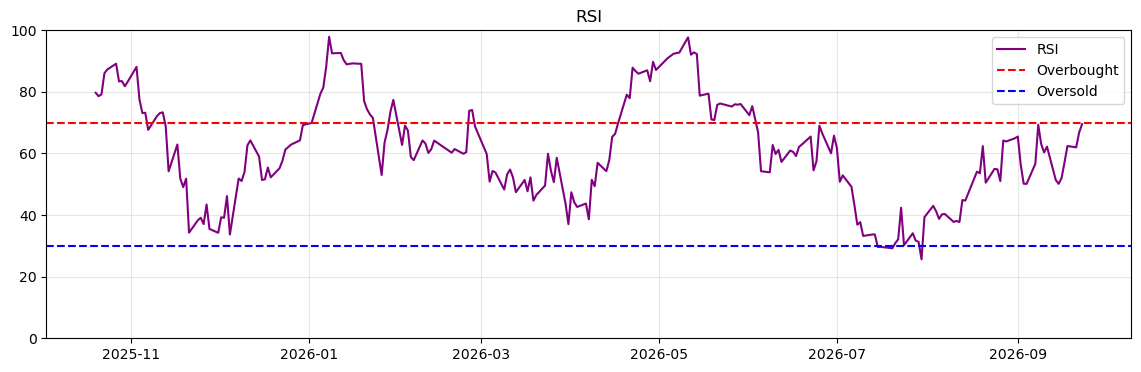

In [18]:
plt.figure(figsize=(14, 4))

plt.plot(
    df.index,
    df["RSI"],
    color="purple",
    label="RSI"
)

plt.axhline(
    70,
    color="red",
    linestyle="--",
    label="Overbought"
)

plt.axhline(
    30,
    color="blue",
    linestyle="--",
    label="Oversold"
)

plt.ylim(0, 100)
plt.title("RSI")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [19]:
# MACD 계산
df["EMA12"] = df["Close"].ewm(
    span=12,
    adjust=False
).mean()

df["EMA26"] = df["Close"].ewm(
    span=26,
    adjust=False
).mean()

df["MACD"] = df["EMA12"] - df["EMA26"]

df["Signal"] = df["MACD"].ewm(
    span=9,
    adjust=False
).mean()

df["Histogram"] = df["MACD"] - df["Signal"]

df[["MACD", "Signal", "Histogram"]].tail()


,MACD,Signal,Histogram
Date,,,
2026-09-17 00:00:00+09:00,13905.542870,5279.324572,8626.218299
2026-09-18 00:00:00+09:00,22465.327572,8716.525172,13748.802400
2026-09-21 00:00:00+09:00,29793.189346,12931.858007,16861.331340
2026-09-22 00:00:00+09:00,32961.249832,16937.736372,16023.513460
2026-09-23 00:00:00+09:00,36822.707479,20914.730593,15907.976886


In [20]:
latest_macd = df["MACD"].iloc[-1]
latest_signal = df["Signal"].iloc[-1]

print(f"MACD: {latest_macd:,.2f}")
print(f"Signal: {latest_signal:,.2f}")

if latest_macd > latest_signal:
    print("MACD 상태: 상승 모멘텀이 상대적으로 강함")
else:
    print("MACD 상태: 하락 모멘텀이 상대적으로 강함")

MACD: 36,822.71
Signal: 20,914.73
MACD 상태: 상승 모멘텀이 상대적으로 강함


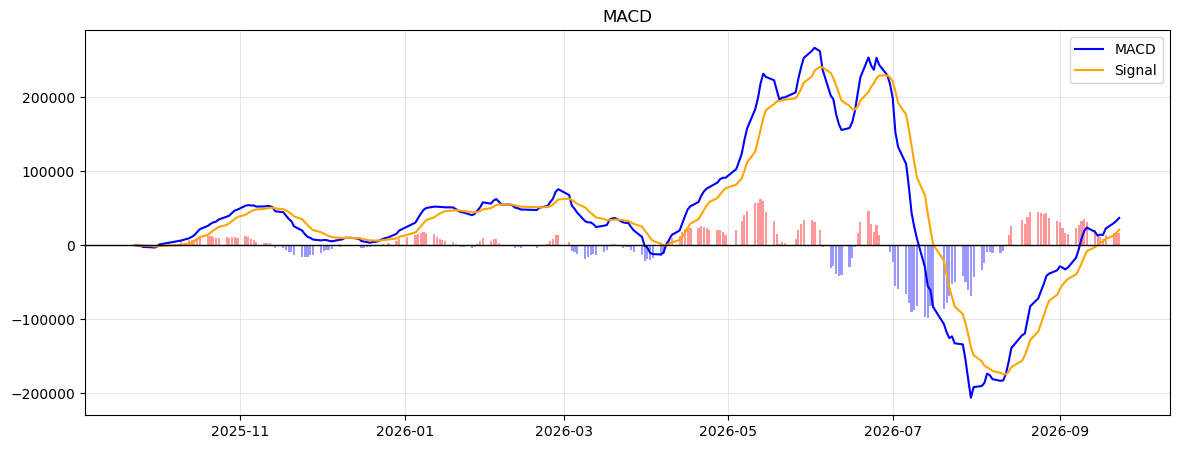

In [21]:
plt.figure(figsize=(14, 5))

plt.plot(
    df.index,
    df["MACD"],
    label="MACD",
    color="blue"
)

plt.plot(
    df.index,
    df["Signal"],
    label="Signal",
    color="orange"
)

colors = [
    "red" if value >= 0 else "blue"
    for value in df["Histogram"]
]

plt.bar(
    df.index,
    df["Histogram"],
    color=colors,
    alpha=0.4
)

plt.axhline(0, color="black", linewidth=1)
plt.title("MACD")
plt.grid(alpha=0.3)
plt.legend()
plt.show()


In [22]:
# 볼린저밴드 계산
df["BB_Middle"] = df["Close"].rolling(20).mean()
df["BB_STD"] = df["Close"].rolling(20).std()

df["BB_Upper"] = (
    df["BB_Middle"] + 2 * df["BB_STD"]
)

df["BB_Lower"] = (
    df["BB_Middle"] - 2 * df["BB_STD"]
)

In [23]:
latest = df.iloc[-1]

price = latest["Close"]
upper = latest["BB_Upper"]
middle = latest["BB_Middle"]
lower = latest["BB_Lower"]

if price >= upper:
    bb_status = "상단 돌파: 강한 상승 또는 단기 과열 가능성"

elif price <= lower:
    bb_status = "하단 이탈: 강한 하락 또는 과매도 가능성"

elif price >= middle:
    bb_status = "중심선 위: 상대적으로 강한 흐름"

else:
    bb_status = "중심선 아래: 상대적으로 약한 흐름"

print(f"볼린저밴드 상태: {bb_status}")

볼린저밴드 상태: 중심선 위: 상대적으로 강한 흐름


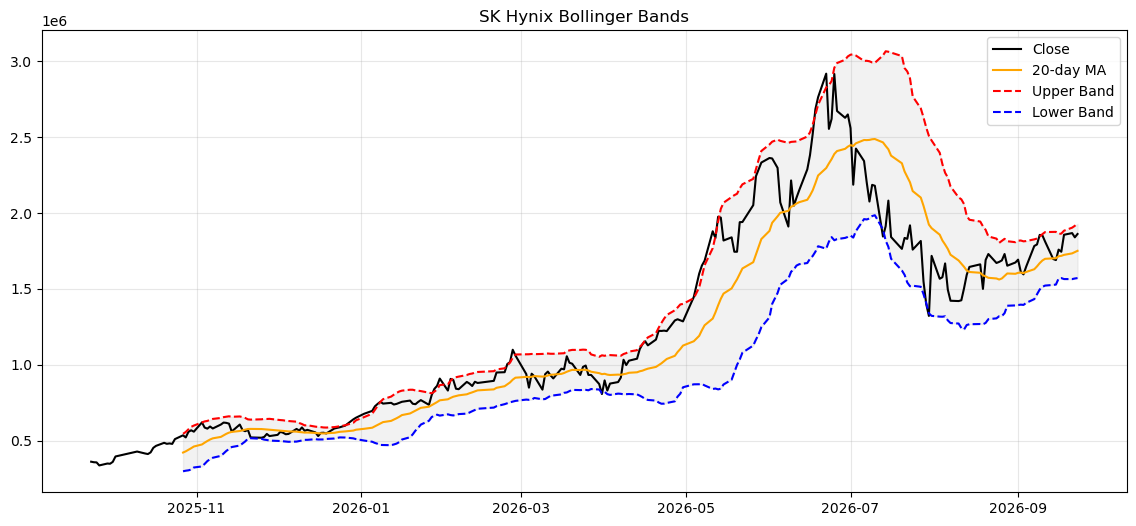

In [24]:
plt.figure(figsize=(14, 6))

plt.plot(
    df.index,
    df["Close"],
    label="Close",
    color="black"
)

plt.plot(
    df.index,
    df["BB_Middle"],
    label="20-day MA",
    color="orange"
)

plt.plot(
    df.index,
    df["BB_Upper"],
    label="Upper Band",
    color="red",
    linestyle="--"
)

plt.plot(
    df.index,
    df["BB_Lower"],
    label="Lower Band",
    color="blue",
    linestyle="--"
)

plt.fill_between(
    df.index,
    df["BB_Lower"],
    df["BB_Upper"],
    color="gray",
    alpha=0.1
)

plt.title("SK Hynix Bollinger Bands")
plt.grid(alpha=0.3)
plt.legend()
plt.show()


In [25]:
high_52week = df["High"].max()
low_52week = df["Low"].min()
current_price = df["Close"].iloc[-1]

distance_from_high = (
    (current_price / high_52week) - 1
) * 100

distance_from_low = (
    (current_price / low_52week) - 1
) * 100

print(f"현재가: {current_price:,.0f}원")
print(f"52주 최고가: {high_52week:,.0f}원")
print(f"52주 최저가: {low_52week:,.0f}원")
print(f"최고가 대비: {distance_from_high:.2f}%")
print(f"최저가 대비: +{distance_from_low:.2f}%")


현재가: 1,862,000원
52주 최고가: 2,987,000원
52주 최저가: 333,000원
최고가 대비: -37.66%
최저가 대비: +459.16%


In [26]:
import numpy as np

df["Return"] = df["Close"].pct_change()

annual_volatility = (
    df["Return"].std() * np.sqrt(252) * 100
)

print(f"연환산 변동성: {annual_volatility:.2f}%")

연환산 변동성: 91.72%


In [27]:
df["Previous_High"] = df["Close"].cummax()

df["Drawdown"] = (
    df["Close"] / df["Previous_High"] - 1
) * 100

max_drawdown = df["Drawdown"].min()

print(f"최근 1년 최대낙폭: {max_drawdown:.2f}%")

최근 1년 최대낙폭: -54.71%


In [28]:
# 이동평균선
df["MA20"] = df["Close"].rolling(20).mean()
df["MA60"] = df["Close"].rolling(60).mean()

# 거래량 이동평균
df["Volume_MA20"] = df["Volume"].rolling(20).mean()

# RSI
period = 14
price_change = df["Close"].diff()

gain = price_change.clip(lower=0)
loss = -price_change.clip(upper=0)

average_gain = gain.rolling(period).mean()
average_loss = loss.rolling(period).mean()

rs = average_gain / average_loss
df["RSI"] = 100 - (100 / (1 + rs))

# MACD
df["EMA12"] = df["Close"].ewm(
    span=12,
    adjust=False
).mean()

df["EMA26"] = df["Close"].ewm(
    span=26,
    adjust=False
).mean()

df["MACD"] = df["EMA12"] - df["EMA26"]

df["Signal"] = df["MACD"].ewm(
    span=9,
    adjust=False
).mean()

df["Histogram"] = df["MACD"] - df["Signal"]

# 볼린저밴드
df["BB_Middle"] = df["Close"].rolling(20).mean()
df["BB_STD"] = df["Close"].rolling(20).std()

df["BB_Upper"] = (
    df["BB_Middle"] + 2 * df["BB_STD"]
)

df["BB_Lower"] = (
    df["BB_Middle"] - 2 * df["BB_STD"]
)

print("모든 분석 지표 계산 완료!")

모든 분석 지표 계산 완료!


In [29]:
df[
    [
        "Close",
        "MA20",
        "MA60",
        "Volume_MA20",
        "RSI",
        "MACD",
        "Signal",
        "BB_Upper",
        "BB_Lower"
    ]
].tail()

,Close,MA20,MA60,Volume_MA20,RSI,MACD,Signal,BB_Upper,BB_Lower
Date,,,,,,,,,
2026-09-17 00:00:00+09:00,1745000.0,1718050.0,1.846233e+06,3371524.40,57.120743,13905.542870,5279.324572,1.864821e+06,1.571279e+06
2026-09-18 00:00:00+09:00,1857000.0,1724400.0,1.833500e+06,3396013.55,62.415197,22465.327572,8716.525172,1.883794e+06,1.565006e+06
2026-09-21 00:00:00+09:00,1868000.0,1734250.0,1.816017e+06,3334052.60,62.002743,29793.189346,12931.858007,1.903775e+06,1.564725e+06
2026-09-22 00:00:00+09:00,1840000.0,1742350.0,1.802133e+06,3296157.95,66.765140,32961.249832,16937.736372,1.915990e+06,1.568710e+06
2026-09-23 00:00:00+09:00,1862000.0,1751050.0,1.789367e+06,3297353.15,69.501466,36822.707479,20914.730593,1.930561e+06,1.571539e+06


In [30]:
# 가장 최근 날짜의 데이터 가져오기
latest = df.iloc[-1]

# 점수 계산에 사용할 변수
price = latest["Close"]
ma20 = latest["MA20"]
ma60 = latest["MA60"]
rsi = latest["RSI"]
macd = latest["MACD"]
signal = latest["Signal"]

volume = latest["Volume"]
volume_ma20 = latest["Volume_MA20"]
volume_ratio = volume / volume_ma20

upper_band = latest["BB_Upper"]
lower_band = latest["BB_Lower"]

print("점수 계산 변수 준비 완료!")
print(f"현재가: {price:,.0f}원")
print(f"20일선: {ma20:,.0f}원")
print(f"60일선: {ma60:,.0f}원")
print(f"RSI: {rsi:.2f}")

점수 계산 변수 준비 완료!
현재가: 1,862,000원
20일선: 1,751,050원
60일선: 1,789,367원
RSI: 69.50


In [31]:
import numpy as np

latest = df.iloc[-1]

price = latest["Close"]
ma20 = latest["MA20"]
ma60 = latest["MA60"]
rsi = latest["RSI"]
macd = latest["MACD"]
signal = latest["Signal"]
volume_ratio = latest["Volume"] / latest["Volume_MA20"]

upper_band = latest["BB_Upper"]
lower_band = latest["BB_Lower"]

# 변동성 계산
daily_returns = df["Close"].pct_change()

annual_volatility = (
    daily_returns.std() * np.sqrt(252) * 100
)

# 최대낙폭 계산
previous_high = df["Close"].cummax()

drawdown = (
    df["Close"] / previous_high - 1
) * 100

max_drawdown = drawdown.min()



In [32]:
# 이동평균선
df["MA20"] = df["Close"].rolling(20).mean()
df["MA60"] = df["Close"].rolling(60).mean()

# 거래량 이동평균
df["Volume_MA20"] = df["Volume"].rolling(20).mean()

# RSI
period = 14
price_change = df["Close"].diff()

gain = price_change.clip(lower=0)
loss = -price_change.clip(upper=0)

average_gain = gain.rolling(period).mean()
average_loss = loss.rolling(period).mean()

rs = average_gain / average_loss
df["RSI"] = 100 - (100 / (1 + rs))

# MACD
df["EMA12"] = df["Close"].ewm(
    span=12,
    adjust=False
).mean()

df["EMA26"] = df["Close"].ewm(
    span=26,
    adjust=False
).mean()

df["MACD"] = df["EMA12"] - df["EMA26"]

df["Signal"] = df["MACD"].ewm(
    span=9,
    adjust=False
).mean()

df["Histogram"] = df["MACD"] - df["Signal"]

# 볼린저밴드
df["BB_Middle"] = df["Close"].rolling(20).mean()
df["BB_STD"] = df["Close"].rolling(20).std()

df["BB_Upper"] = (
    df["BB_Middle"] + 2 * df["BB_STD"]
)

df["BB_Lower"] = (
    df["BB_Middle"] - 2 * df["BB_STD"]
)

print("모든 분석 지표 계산 완료!")

모든 분석 지표 계산 완료!


In [33]:
up_score = 0
up_reasons = []

# 1. 현재가가 20일선 위
if price > ma20:
    up_score += 1
    up_reasons.append("현재가가 20일 이동평균선 위")

# 2. 20일선이 60일선 위
if ma20 > ma60:
    up_score += 1
    up_reasons.append("20일선이 60일선 위")

# 3. RSI가 50~70
if 50 <= rsi < 70:
    up_score += 1
    up_reasons.append("RSI 상승 우위, 과열 전 구간")

# 4. MACD가 Signal 위
if macd > signal:
    up_score += 1
    up_reasons.append("MACD 상승 모멘텀")

# 5. 거래량이 20일 평균 이상
if volume_ratio >= 1:
    up_score += 1
    up_reasons.append("거래량이 20일 평균 이상")

In [34]:
risk_score = 0
risk_reasons = []

# 1. RSI 과열
if rsi >= 70:
    risk_score += 1
    risk_reasons.append("RSI 70 이상으로 단기 과열 가능성")

# 2. 볼린저밴드 상단 돌파
if price >= upper_band:
    risk_score += 1
    risk_reasons.append("볼린저밴드 상단 이상")

# 3. 변동성 40% 이상
if annual_volatility >= 40:
    risk_score += 1
    risk_reasons.append("연환산 변동성 40% 이상")

# 4. 과거 최대낙폭 30% 이상
if max_drawdown <= -30:
    risk_score += 1
    risk_reasons.append("최근 기간 최대낙폭 30% 이상")

# 5. 거래량이 평소의 2배 이상
if volume_ratio >= 2:
    risk_score += 1
    risk_reasons.append("거래량이 평소의 2배 이상")

In [35]:
if up_score >= 4:
    up_status = "상승 조건이 비교적 강함"

elif up_score >= 2:
    up_status = "일부 상승 조건 충족"

else:
    up_status = "상승 조건이 약함"


if risk_score >= 4:
    risk_status = "위험 신호가 많음"

elif risk_score >= 2:
    risk_status = "일부 위험 신호 존재"

else:
    risk_status = "현재 기준 위험 신호가 적음"


print("===== 종합 분석 결과 =====")
print(f"상승 조건 점수: {up_score}/5")
print(f"판정: {up_status}")

for reason in up_reasons:
    print(f"  + {reason}")

print()
print(f"위험 점수: {risk_score}/5")
print(f"판정: {risk_status}")

for reason in risk_reasons:
    print(f"  ! {reason}")

print()
print(f"현재가: {price:,.0f}원")
print(f"RSI: {rsi:.2f}")
print(f"평균 대비 거래량: {volume_ratio:.2f}배")
print(f"연환산 변동성: {annual_volatility:.2f}%")
print(f"최근 기간 최대낙폭: {max_drawdown:.2f}%")

===== 종합 분석 결과 =====
상승 조건 점수: 3/5
판정: 일부 상승 조건 충족
  + 현재가가 20일 이동평균선 위
  + RSI 상승 우위, 과열 전 구간
  + MACD 상승 모멘텀

위험 점수: 2/5
판정: 일부 위험 신호 존재
  ! 연환산 변동성 40% 이상
  ! 최근 기간 최대낙폭 30% 이상

현재가: 1,862,000원
RSI: 69.50
평균 대비 거래량: 0.89배
연환산 변동성: 91.72%
최근 기간 최대낙폭: -54.71%


In [36]:
# 최신 데이터 한 줄 가져오기
latest = df.dropna().iloc[-1]

price = float(latest["Close"])
ma20 = float(latest["MA20"])
ma60 = float(latest["MA60"])
rsi = float(latest["RSI"])
macd = float(latest["MACD"])
signal = float(latest["Signal"])
volume_ratio = float(latest["Volume"] / latest["Volume_MA20"])

# 상승 신호 점수 계산
up_score = 0
up_reasons = []

if price > ma20:
    up_score += 1
    up_reasons.append("현재가가 20일 이동평균선 위")

if ma20 > ma60:
    up_score += 1
    up_reasons.append("20일선이 60일선 위")

if 50 <= rsi < 70:
    up_score += 1
    up_reasons.append("RSI 상승 우위이며 과열 전")

if macd > signal:
    up_score += 1
    up_reasons.append("MACD 상승 모멘텀")

if volume_ratio >= 1:
    up_score += 1
    up_reasons.append("거래량이 20일 평균 이상")

print("===== SK하이닉스 상승 신호 분석 =====")
print(f"현재가: {price:,.0f}원")
print(f"MA20: {ma20:,.0f}원")
print(f"MA60: {ma60:,.0f}원")
print(f"RSI: {rsi:.1f}")
print(f"MACD: {macd:,.1f}")
print(f"Signal: {signal:,.1f}")
print(f"평균 대비 거래량: {volume_ratio:.2f}배")
print(f"상승 신호 점수: {up_score}/5")

print("\n상승 근거:")
if up_reasons:
    for reason in up_reasons:
        print("-", reason)
else:
    print("- 뚜렷한 상승 신호가 없습니다.")

if up_score >= 4:
    print("\n판정: 상승 신호가 강한 편")
elif up_score >= 2:
    print("\n판정: 상승 신호가 일부 존재")
else:
    print("\n판정: 상승 신호가 약한 편")

===== SK하이닉스 상승 신호 분석 =====
현재가: 1,862,000원
MA20: 1,751,050원
MA60: 1,789,367원
RSI: 69.5
MACD: 36,822.7
Signal: 20,914.7
평균 대비 거래량: 0.89배
상승 신호 점수: 3/5

상승 근거:
- 현재가가 20일 이동평균선 위
- RSI 상승 우위이며 과열 전
- MACD 상승 모멘텀

판정: 상승 신호가 일부 존재


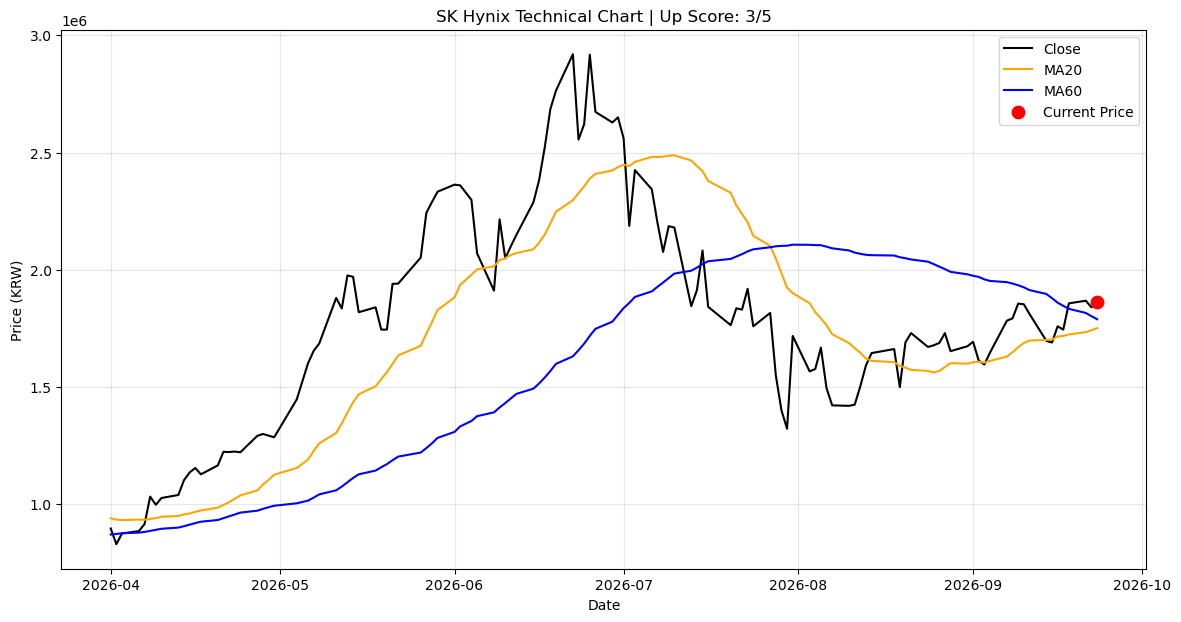

In [37]:
import matplotlib.pyplot as plt

# 최근 6개월만 표시
chart_df = df.dropna().tail(120)

plt.figure(figsize=(14, 7))

plt.plot(
    chart_df.index,
    chart_df["Close"],
    label="Close",
    color="black",
    linewidth=1.5
)

plt.plot(
    chart_df.index,
    chart_df["MA20"],
    label="MA20",
    color="orange"
)

plt.plot(
    chart_df.index,
    chart_df["MA60"],
    label="MA60",
    color="blue"
)

# 현재가 표시
plt.scatter(
    chart_df.index[-1],
    chart_df["Close"].iloc[-1],
    color="red",
    s=80,
    label="Current Price",
    zorder=5
)

plt.title(f"SK Hynix Technical Chart | Up Score: {up_score}/5")
plt.xlabel("Date")
plt.ylabel("Price (KRW)")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

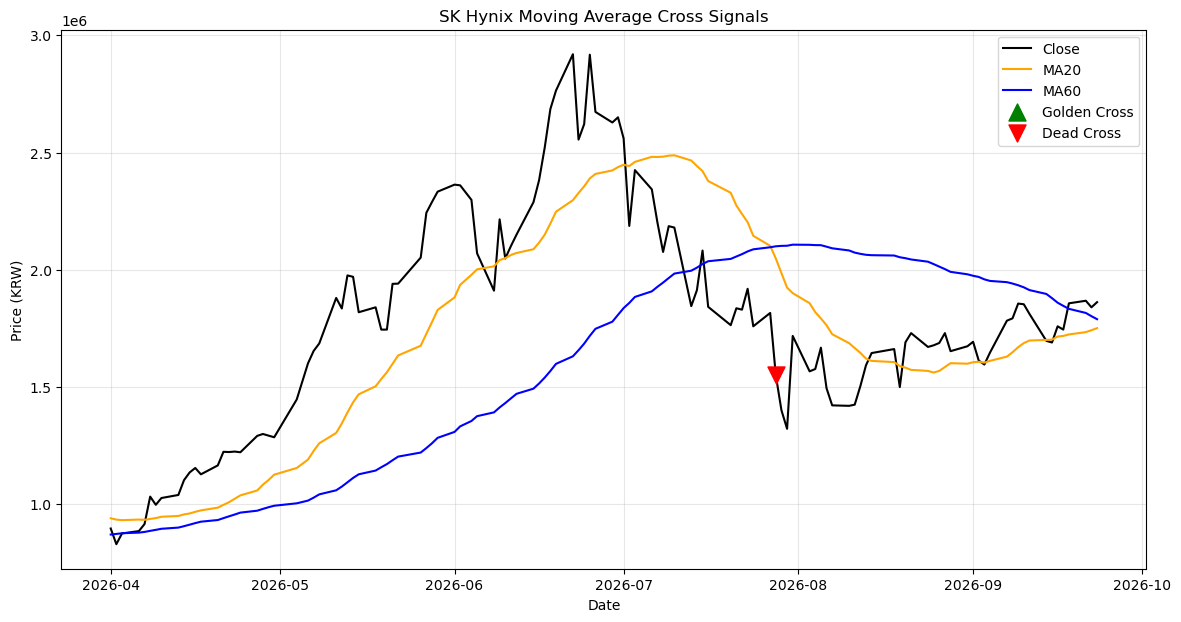

최근 골든크로스 날짜:
[]

최근 데드크로스 날짜:
['2026-07-28']


In [38]:
import matplotlib.pyplot as plt

# 이동평균선 차이
df["MA_Difference"] = df["MA20"] - df["MA60"]

# 골든크로스: MA20이 MA60을 아래에서 위로 돌파
df["Golden_Cross"] = (
    (df["MA_Difference"] > 0) &
    (df["MA_Difference"].shift(1) <= 0)
)

# 데드크로스: MA20이 MA60을 위에서 아래로 돌파
df["Dead_Cross"] = (
    (df["MA_Difference"] < 0) &
    (df["MA_Difference"].shift(1) >= 0)
)

# 최근 120거래일
chart_df = df.dropna(subset=["MA20", "MA60"]).tail(120)

golden = chart_df[chart_df["Golden_Cross"]]
dead = chart_df[chart_df["Dead_Cross"]]

plt.figure(figsize=(14, 7))

plt.plot(
    chart_df.index,
    chart_df["Close"],
    label="Close",
    color="black",
    linewidth=1.5
)

plt.plot(
    chart_df.index,
    chart_df["MA20"],
    label="MA20",
    color="orange"
)

plt.plot(
    chart_df.index,
    chart_df["MA60"],
    label="MA60",
    color="blue"
)

# 골든크로스 표시
plt.scatter(
    golden.index,
    golden["Close"],
    marker="^",
    color="green",
    s=150,
    label="Golden Cross",
    zorder=5
)

# 데드크로스 표시
plt.scatter(
    dead.index,
    dead["Close"],
    marker="v",
    color="red",
    s=150,
    label="Dead Cross",
    zorder=5
)

plt.title("SK Hynix Moving Average Cross Signals")
plt.xlabel("Date")
plt.ylabel("Price (KRW)")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

print("최근 골든크로스 날짜:")
print(golden.index.strftime("%Y-%m-%d").tolist())

print("\n최근 데드크로스 날짜:")
print(dead.index.strftime("%Y-%m-%d").tolist())

In [39]:
import pandas as pd

# 보유 기간 설정
holding_days = 20

results = []

# 골든크로스가 발생한 날짜마다 계산
for signal_date in df.index[df["Golden_Cross"]]:
    signal_position = df.index.get_loc(signal_date)
    sell_position = signal_position + holding_days

    # 이후 데이터가 20일 이상 남은 신호만 계산
    if sell_position < len(df):
        buy_price = float(df["Close"].iloc[signal_position])
        sell_price = float(df["Close"].iloc[sell_position])

        return_rate = (sell_price / buy_price - 1) * 100

        results.append({
            "매수일": signal_date.strftime("%Y-%m-%d"),
            "매수가": round(buy_price),
            "매도일": df.index[sell_position].strftime("%Y-%m-%d"),
            "매도가": round(sell_price),
            "수익률(%)": round(return_rate, 2)
        })

result_df = pd.DataFrame(results)

if result_df.empty:
    print("계산 가능한 골든크로스가 없습니다.")
else:
    display(result_df)

    win_rate = (result_df["수익률(%)"] > 0).mean() * 100
    average_return = result_df["수익률(%)"].mean()
    cumulative_return = (
        (1 + result_df["수익률(%)"] / 100).prod() - 1
    ) * 100

    print(f"거래 횟수: {len(result_df)}회")
    print(f"승률: {win_rate:.1f}%")
    print(f"평균 수익률: {average_return:.2f}%")
    print(f"단순 재투자 누적 수익률: {cumulative_return:.2f}%")

계산 가능한 골든크로스가 없습니다.


In [40]:
print("전체 골든크로스 개수:", df["Golden_Cross"].sum())
print("전체 데드크로스 개수:", df["Dead_Cross"].sum())

print("\n골든크로스 날짜:")
print(df.index[df["Golden_Cross"]].strftime("%Y-%m-%d").tolist())

print("\n데드크로스 날짜:")
print(df.index[df["Dead_Cross"]].strftime("%Y-%m-%d").tolist())

전체 골든크로스 개수: 0
전체 데드크로스 개수: 1

골든크로스 날짜:
[]

데드크로스 날짜:
['2026-07-28']


데이터 기간: 2021-09-23 ~ 2026-09-23
골든크로스: 7 회
데드크로스: 8 회

골든크로스 날짜:
['2023-01-27', '2023-05-02', '2023-10-12', '2024-10-22', '2025-01-13', '2025-05-23', '2025-09-16']

데드크로스 날짜:
['2022-03-16', '2023-03-21', '2023-10-10', '2024-08-05', '2024-12-03', '2025-04-03', '2025-08-26', '2026-07-28']


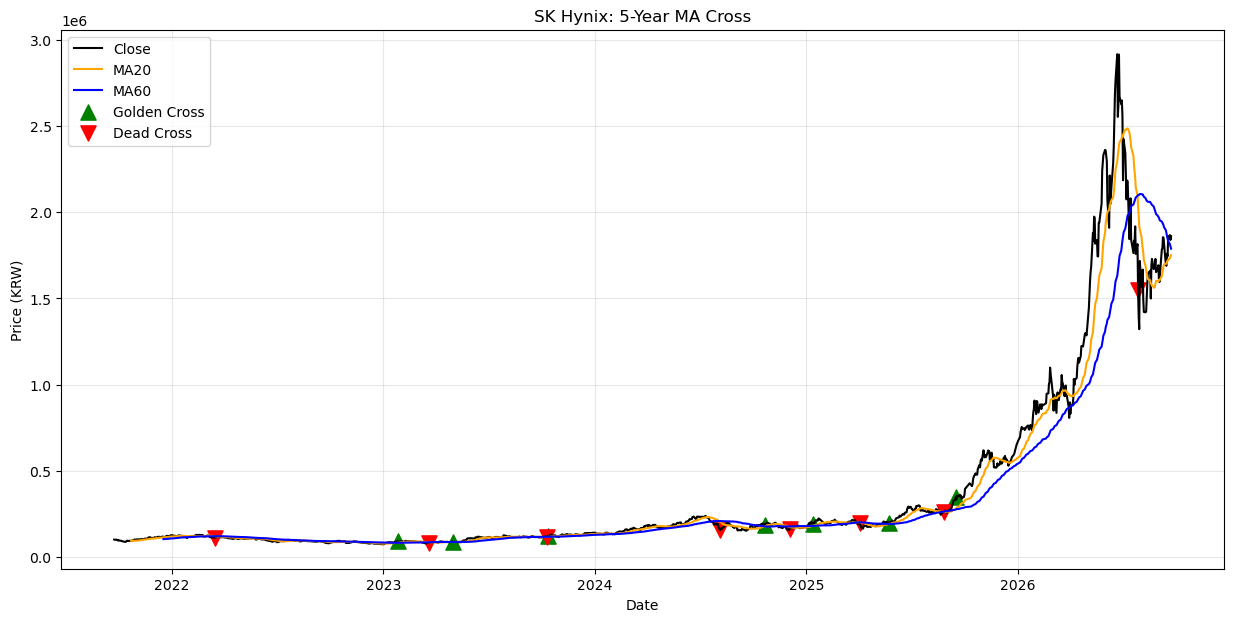

In [41]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# SK하이닉스 5년 데이터
df = yf.Ticker("000660.KS").history(period="5y")

# 이동평균선 계산
df["MA20"] = df["Close"].rolling(20).mean()
df["MA60"] = df["Close"].rolling(60).mean()

# 전날에는 MA20이 MA60 이하였는데 오늘 위로 올라오면 골든크로스
df["Golden_Cross"] = (
    (df["MA20"] > df["MA60"]) &
    (df["MA20"].shift(1) <= df["MA60"].shift(1))
)

# 전날에는 MA20이 MA60 이상이었는데 오늘 아래로 내려가면 데드크로스
df["Dead_Cross"] = (
    (df["MA20"] < df["MA60"]) &
    (df["MA20"].shift(1) >= df["MA60"].shift(1))
)

golden = df[df["Golden_Cross"]]
dead = df[df["Dead_Cross"]]

print("데이터 기간:", df.index[0].date(), "~", df.index[-1].date())
print("골든크로스:", len(golden), "회")
print("데드크로스:", len(dead), "회")

print("\n골든크로스 날짜:")
print([date.strftime("%Y-%m-%d") for date in golden.index])

print("\n데드크로스 날짜:")
print([date.strftime("%Y-%m-%d") for date in dead.index])

# 5년 차트
plt.figure(figsize=(15, 7))

plt.plot(df.index, df["Close"], color="black", label="Close")
plt.plot(df.index, df["MA20"], color="orange", label="MA20")
plt.plot(df.index, df["MA60"], color="blue", label="MA60")

plt.scatter(
    golden.index,
    golden["Close"],
    color="green",
    marker="^",
    s=120,
    label="Golden Cross"
)

plt.scatter(
    dead.index,
    dead["Close"],
    color="red",
    marker="v",
    s=120,
    label="Dead Cross"
)

plt.title("SK Hynix: 5-Year MA Cross")
plt.xlabel("Date")
plt.ylabel("Price (KRW)")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [42]:
results = []

for buy_date in df.index[df["Golden_Cross"]]:
    buy_position = df.index.get_loc(buy_date)
    sell_position = buy_position + 20

    if sell_position < len(df):
        buy_price = float(df["Close"].iloc[buy_position])
        sell_price = float(df["Close"].iloc[sell_position])
        return_rate = (sell_price / buy_price - 1) * 100

        results.append({
            "골든크로스 날짜": buy_date.strftime("%Y-%m-%d"),
            "매수가": round(buy_price),
            "20일 후 가격": round(sell_price),
            "수익률(%)": round(return_rate, 2),
            "결과": "수익" if return_rate > 0 else "손실"
        })

result_df = pd.DataFrame(results)
display(result_df)

win_rate = (result_df["수익률(%)"] > 0).mean() * 100
average_return = result_df["수익률(%)"].mean()
best_return = result_df["수익률(%)"].max()
worst_return = result_df["수익률(%)"].min()

print(f"분석 횟수: {len(result_df)}회")
print(f"승률: {win_rate:.1f}%")
print(f"평균 수익률: {average_return:.2f}%")
print(f"최고 수익률: {best_return:.2f}%")
print(f"최저 수익률: {worst_return:.2f}%")

,골든크로스 날짜,매수가,20일 후 가격,수익률(%),결과
0,2023-01-27,88973,88487,-0.55,손실
1,2023-05-02,88013,107626,22.28,수익
2,2023-10-12,121820,125547,3.06,수익
3,2024-10-22,185442,168458,-9.16,손실
4,2025-01-13,191860,207363,8.08,수익
5,2025-05-23,198766,277281,39.50,수익
6,2025-09-16,346977,480085,38.36,수익


분석 횟수: 7회
승률: 71.4%
평균 수익률: 14.51%
최고 수익률: 39.50%
최저 수익률: -9.16%


In [43]:
holding_periods = [5, 10, 20, 40, 60]
comparison = []

for days in holding_periods:
    returns = []

    for buy_date in df.index[df["Golden_Cross"]]:
        buy_position = df.index.get_loc(buy_date)
        sell_position = buy_position + days

        if sell_position < len(df):
            buy_price = float(df["Close"].iloc[buy_position])
            sell_price = float(df["Close"].iloc[sell_position])
            return_rate = (sell_price / buy_price - 1) * 100
            returns.append(return_rate)

    if returns:
        comparison.append({
            "보유기간(거래일)": days,
            "거래횟수": len(returns),
            "승률(%)": round(
                sum(r > 0 for r in returns) / len(returns) * 100, 1
            ),
            "평균수익률(%)": round(sum(returns) / len(returns), 2),
            "최고수익률(%)": round(max(returns), 2),
            "최저수익률(%)": round(min(returns), 2)
        })

comparison_df = pd.DataFrame(comparison)
display(comparison_df)

,보유기간(거래일),거래횟수,승률(%),평균수익률(%),최고수익률(%),최저수익률(%)
0,5,7,85.7,1.99,9.11,-3.66
1,10,7,85.7,3.57,15.46,-3.38
2,20,7,71.4,14.51,39.50,-9.16
3,40,7,71.4,17.61,61.49,-6.56
4,60,7,71.4,20.39,58.45,-6.66


In [44]:
trade_results = []

take_profit = 0.10   # 익절 +10%
stop_loss = -0.05    # 손절 -5%
max_holding = 20     # 최대 20거래일 보유

for signal_date in df.index[df["Golden_Cross"]]:
    signal_position = df.index.get_loc(signal_date)
    buy_position = signal_position + 1

    # 다음 날 데이터가 없으면 건너뛰기
    if buy_position >= len(df):
        continue

    # 신호를 확인한 다음 날 시가에 매수
    buy_date = df.index[buy_position]
    buy_price = float(df["Open"].iloc[buy_position])

    sell_price = None
    sell_date = None
    sell_reason = None

    last_position = min(
        buy_position + max_holding,
        len(df) - 1
    )

    # 매수일부터 최대 20거래일 동안 확인
    for position in range(buy_position, last_position + 1):
        day_high = float(df["High"].iloc[position])
        day_low = float(df["Low"].iloc[position])

        profit_rate = day_high / buy_price - 1
        loss_rate = day_low / buy_price - 1

        # 같은 날 익절·손절 가격에 모두 닿은 경우
        # 보수적으로 손절이 먼저 발생했다고 가정
        if loss_rate <= stop_loss:
            sell_price = buy_price * (1 + stop_loss)
            sell_date = df.index[position]
            sell_reason = "손절"
            break

        elif profit_rate >= take_profit:
            sell_price = buy_price * (1 + take_profit)
            sell_date = df.index[position]
            sell_reason = "익절"
            break

    # 익절·손절 모두 없으면 마지막 날 종가에 매도
    if sell_price is None:
        sell_price = float(df["Close"].iloc[last_position])
        sell_date = df.index[last_position]
        sell_reason = "기간 종료"

    return_rate = (sell_price / buy_price - 1) * 100

    trade_results.append({
        "신호일": signal_date.strftime("%Y-%m-%d"),
        "매수일": buy_date.strftime("%Y-%m-%d"),
        "매수가": round(buy_price),
        "매도일": sell_date.strftime("%Y-%m-%d"),
        "매도가": round(sell_price),
        "매도 이유": sell_reason,
        "수익률(%)": round(return_rate, 2)
    })

risk_test_df = pd.DataFrame(trade_results)
display(risk_test_df)

if not risk_test_df.empty:
    win_rate = (
        risk_test_df["수익률(%)"] > 0
    ).mean() * 100

    average_return = risk_test_df["수익률(%)"].mean()

    print(f"거래 횟수: {len(risk_test_df)}회")
    print(f"승률: {win_rate:.1f}%")
    print(f"평균 수익률: {average_return:.2f}%")
    print("\n매도 이유별 횟수:")
    print(risk_test_df["매도 이유"].value_counts())

,신호일,매수일,매수가,매도일,매도가,매도 이유,수익률(%)
0,2023-01-27,2023-01-30,88779,2023-02-27,87515,기간 종료,-1.42
1,2023-05-02,2023-05-03,86842,2023-05-22,95526,익절,10.00
2,2023-10-12,2023-10-13,120741,2023-10-31,114704,손절,-5.00
3,2024-10-22,2024-10-23,186133,2024-11-14,176826,손절,-5.00
4,2025-01-13,2025-01-14,191860,2025-01-17,211046,익절,10.00
5,2025-05-23,2025-05-26,198766,2025-06-04,218642,익절,10.00
6,2025-09-16,2025-09-17,339998,2025-10-02,373998,익절,10.00


거래 횟수: 7회
승률: 57.1%
평균 수익률: 4.08%

매도 이유별 횟수:
매도 이유
익절       4
손절       2
기간 종료    1
Name: count, dtype: int64


초기 자금: 1,000,000원
최종 자금: 1,276,414원
누적 수익률: 27.64%
순이익: 276,414원


C:\Users\손지우\AppData\Local\Temp\ipykernel_61716\3720226441.py:55: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\손지우\AppData\Local\Temp\ipykernel_61716\3720226441.py:55: UserWarning: Glyph 51089 (\N{HANGUL SYLLABLE JAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51089 (\N{HANGUL SYLLABLE JAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


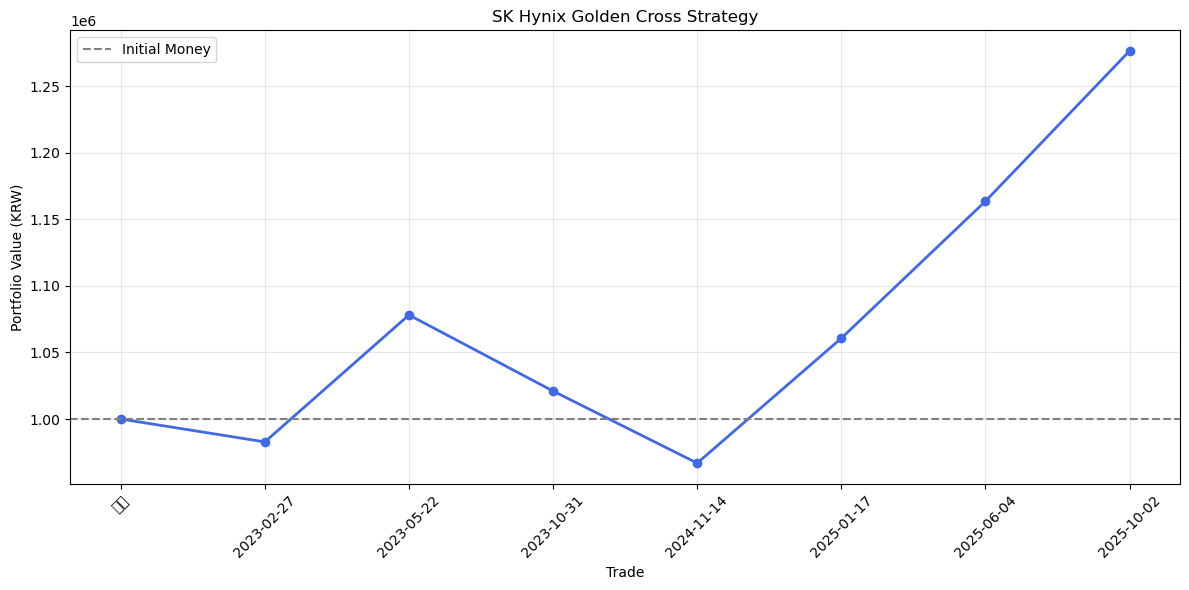

In [45]:
import matplotlib.pyplot as plt

initial_money = 1_000_000
money = initial_money

fee_rate = 0.3  # 왕복 수수료·세금 가정치(%)

money_history = [money]
trade_labels = ["시작"]

for _, trade in risk_test_df.iterrows():
    gross_return = trade["수익률(%)"]
    net_return = gross_return - fee_rate

    money = money * (1 + net_return / 100)

    money_history.append(money)
    trade_labels.append(trade["매도일"])

final_return = (money / initial_money - 1) * 100

print(f"초기 자금: {initial_money:,.0f}원")
print(f"최종 자금: {money:,.0f}원")
print(f"누적 수익률: {final_return:.2f}%")
print(f"순이익: {money - initial_money:,.0f}원")

plt.figure(figsize=(12, 6))

plt.plot(
    range(len(money_history)),
    money_history,
    marker="o",
    color="royalblue",
    linewidth=2
)

plt.axhline(
    initial_money,
    color="gray",
    linestyle="--",
    label="Initial Money"
)

plt.xticks(
    range(len(trade_labels)),
    trade_labels,
    rotation=45
)

plt.title("SK Hynix Golden Cross Strategy")
plt.xlabel("Trade")
plt.ylabel("Portfolio Value (KRW)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [46]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

===== 전략 비교 =====
골든크로스 전략: 27.64%
단순 보유 전략: 344.18%
결론: 단순 보유가 골든크로스 전략보다 우수


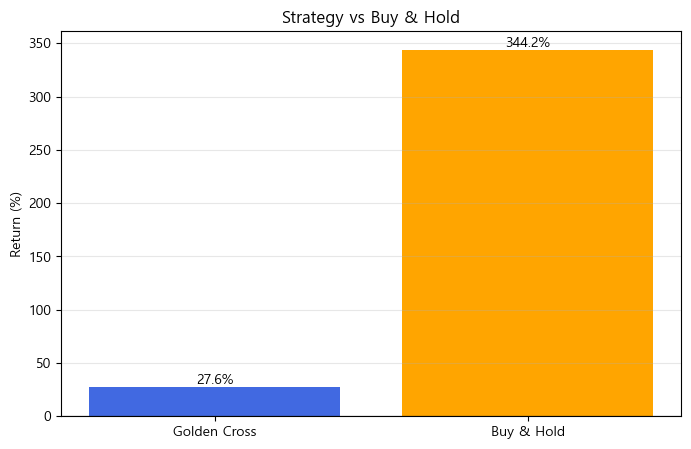

In [47]:
# 전략 기간 설정
start_date = risk_test_df["매수일"].iloc[0]
end_date = risk_test_df["매도일"].iloc[-1]

comparison_data = df.loc[start_date:end_date]

# 같은 기간 단순 보유 수익률
start_price = float(comparison_data["Open"].iloc[0])
end_price = float(comparison_data["Close"].iloc[-1])

buy_hold_return = (
    end_price / start_price - 1
) * 100

# 골든크로스 전략 수익률
strategy_return = (
    money / initial_money - 1
) * 100

print("===== 전략 비교 =====")
print(f"골든크로스 전략: {strategy_return:.2f}%")
print(f"단순 보유 전략: {buy_hold_return:.2f}%")

if strategy_return > buy_hold_return:
    print("결론: 골든크로스 전략이 단순 보유보다 우수")
else:
    print("결론: 단순 보유가 골든크로스 전략보다 우수")

# 막대그래프
labels = ["Golden Cross", "Buy & Hold"]
returns = [strategy_return, buy_hold_return]
colors = ["royalblue", "orange"]

plt.figure(figsize=(8, 5))
bars = plt.bar(labels, returns, color=colors)

plt.axhline(0, color="black", linewidth=0.8)
plt.ylabel("Return (%)")
plt.title("Strategy vs Buy & Hold")

for bar, value in zip(bars, returns):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.1f}%",
        ha="center",
        va="bottom" if value >= 0 else "top"
    )

plt.grid(axis="y", alpha=0.3)
plt.show()

===== 위험 비교 =====
골든크로스 전략 수익률: 27.64%
골든크로스 전략 MDD: -10.32%

단순 보유 수익률: 344.18%
단순 보유 MDD: -36.60%


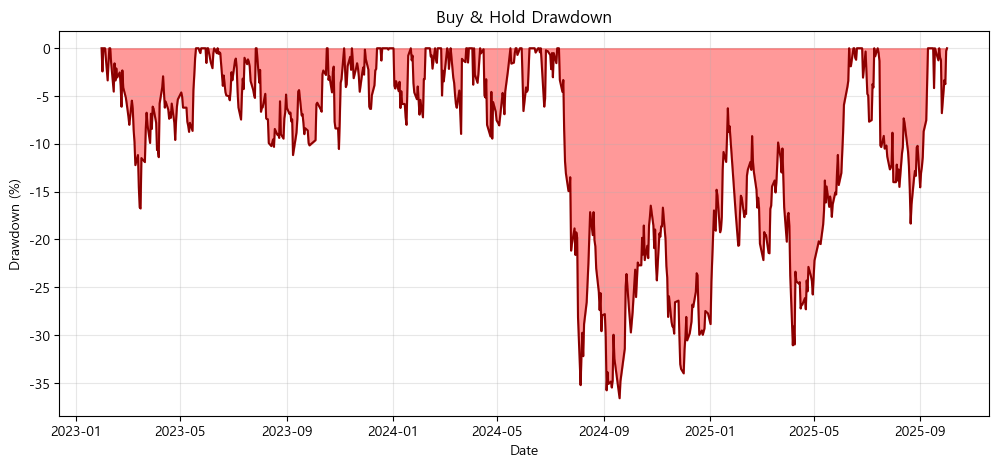

In [48]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 단순 보유 자산 변화
buy_hold_value = (
    comparison_data["Close"] / comparison_data["Close"].iloc[0]
) * initial_money

buy_hold_peak = buy_hold_value.cummax()

buy_hold_drawdown = (
    buy_hold_value / buy_hold_peak - 1
) * 100

buy_hold_mdd = buy_hold_drawdown.min()


# 2. 골든크로스 전략의 거래 종료 시점 자산 변화
strategy_value = pd.Series(
    money_history,
    index=trade_labels
)

strategy_peak = strategy_value.cummax()

strategy_drawdown = (
    strategy_value / strategy_peak - 1
) * 100

strategy_mdd = strategy_drawdown.min()


print("===== 위험 비교 =====")
print(f"골든크로스 전략 수익률: {strategy_return:.2f}%")
print(f"골든크로스 전략 MDD: {strategy_mdd:.2f}%")
print()
print(f"단순 보유 수익률: {buy_hold_return:.2f}%")
print(f"단순 보유 MDD: {buy_hold_mdd:.2f}%")

# 단순 보유 낙폭 그래프
plt.figure(figsize=(12, 5))

plt.fill_between(
    buy_hold_drawdown.index,
    buy_hold_drawdown.values,
    0,
    color="red",
    alpha=0.4
)

plt.plot(
    buy_hold_drawdown.index,
    buy_hold_drawdown,
    color="darkred"
)

plt.title("Buy & Hold Drawdown")
plt.xlabel("Date")
plt.ylabel("Drawdown (%)")
plt.grid(alpha=0.3)
plt.show()

,전략,누적 수익률(%),MDD(%)
0,골든크로스,27.64,-10.32
1,단순 보유,344.18,-36.60


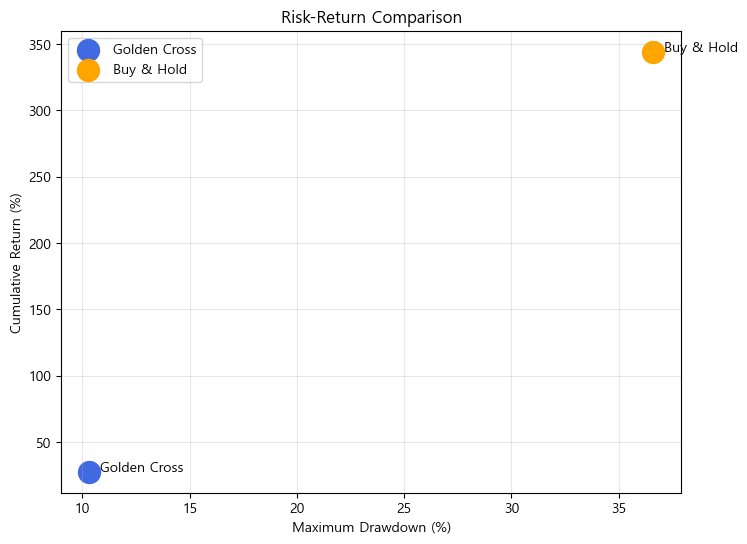

===== 최종 분석 =====
수익률은 단순 보유 전략이 더 높았습니다.
위험 관리 측면에서는 골든크로스 전략이 더 안정적이었습니다.

결론: SK하이닉스의 강한 상승장에서는 단순 보유가 유리했지만, 골든크로스 전략은 상승 수익 일부를 포기하는 대신 낙폭을 줄였습니다.


In [49]:
summary_df = pd.DataFrame({
    "전략": ["골든크로스", "단순 보유"],
    "누적 수익률(%)": [
        round(strategy_return, 2),
        round(buy_hold_return, 2)
    ],
    "MDD(%)": [
        round(strategy_mdd, 2),
        round(buy_hold_mdd, 2)
    ]
})

display(summary_df)

plt.figure(figsize=(8, 6))

plt.scatter(
    abs(strategy_mdd),
    strategy_return,
    s=250,
    color="royalblue",
    label="Golden Cross"
)

plt.scatter(
    abs(buy_hold_mdd),
    buy_hold_return,
    s=250,
    color="orange",
    label="Buy & Hold"
)

plt.text(
    abs(strategy_mdd) + 0.5,
    strategy_return,
    "Golden Cross"
)

plt.text(
    abs(buy_hold_mdd) + 0.5,
    buy_hold_return,
    "Buy & Hold"
)

plt.xlabel("Maximum Drawdown (%)")
plt.ylabel("Cumulative Return (%)")
plt.title("Risk-Return Comparison")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

print("===== 최종 분석 =====")

if buy_hold_return > strategy_return:
    print("수익률은 단순 보유 전략이 더 높았습니다.")
else:
    print("수익률은 골든크로스 전략이 더 높았습니다.")

if abs(strategy_mdd) < abs(buy_hold_mdd):
    print("위험 관리 측면에서는 골든크로스 전략이 더 안정적이었습니다.")
else:
    print("위험 관리 측면에서는 단순 보유 전략이 더 안정적이었습니다.")

print(
    "\n결론: SK하이닉스의 강한 상승장에서는 단순 보유가 유리했지만, "
    "골든크로스 전략은 상승 수익 일부를 포기하는 대신 낙폭을 줄였습니다."
)

In [50]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

def analyze_stock(ticker, stock_name, period="5y"):
    # 1. 데이터 가져오기
    data = yf.Ticker(ticker).history(period=period)

    # 2. 이동평균선 계산
    data["MA20"] = data["Close"].rolling(20).mean()
    data["MA60"] = data["Close"].rolling(60).mean()

    # 3. 골든크로스와 데드크로스
    data["Golden_Cross"] = (
        (data["MA20"] > data["MA60"]) &
        (data["MA20"].shift(1) <= data["MA60"].shift(1))
    )

    data["Dead_Cross"] = (
        (data["MA20"] < data["MA60"]) &
        (data["MA20"].shift(1) >= data["MA60"].shift(1))
    )

    golden = data[data["Golden_Cross"]]
    dead = data[data["Dead_Cross"]]

    # 4. 최신 데이터
    latest = data.dropna(subset=["MA20", "MA60"]).iloc[-1]

    price = float(latest["Close"])
    ma20 = float(latest["MA20"])
    ma60 = float(latest["MA60"])

    if ma20 > ma60:
        trend = "상승 추세 우위"
    else:
        trend = "하락 추세 또는 조정 구간"

    # 5. 결과 출력
    print(f"===== {stock_name} 분석 =====")
    print(f"티커: {ticker}")
    print(f"현재가: {price:,.0f}")
    print(f"20일 이동평균: {ma20:,.0f}")
    print(f"60일 이동평균: {ma60:,.0f}")
    print(f"현재 상태: {trend}")
    print(f"5년간 골든크로스: {len(golden)}회")
    print(f"5년간 데드크로스: {len(dead)}회")

    if len(golden) > 0:
        last_golden = golden.index[-1].strftime("%Y-%m-%d")
        print(f"최근 골든크로스: {last_golden}")

    if len(dead) > 0:
        last_dead = dead.index[-1].strftime("%Y-%m-%d")
        print(f"최근 데드크로스: {last_dead}")

    # 6. 최근 1년 그래프
    chart_data = data.tail(252)
    chart_golden = chart_data[chart_data["Golden_Cross"]]
    chart_dead = chart_data[chart_data["Dead_Cross"]]

    plt.figure(figsize=(14, 7))

    plt.plot(
        chart_data.index,
        chart_data["Close"],
        color="black",
        label="Close"
    )

    plt.plot(
        chart_data.index,
        chart_data["MA20"],
        color="orange",
        label="MA20"
    )

    plt.plot(
        chart_data.index,
        chart_data["MA60"],
        color="blue",
        label="MA60"
    )

    plt.scatter(
        chart_golden.index,
        chart_golden["Close"],
        color="green",
        marker="^",
        s=150,
        label="Golden Cross"
    )

    plt.scatter(
        chart_dead.index,
        chart_dead["Close"],
        color="red",
        marker="v",
        s=150,
        label="Dead Cross"
    )

    plt.title(f"{stock_name} Technical Analysis")
    plt.xlabel("Date")
    plt.ylabel("Price")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

    return data

===== SK Hynix 분석 =====
티커: 000660.KS
현재가: 1,862,000
20일 이동평균: 1,751,031
60일 이동평균: 1,789,099
현재 상태: 하락 추세 또는 조정 구간
5년간 골든크로스: 7회
5년간 데드크로스: 8회
최근 골든크로스: 2025-09-16
최근 데드크로스: 2026-07-28


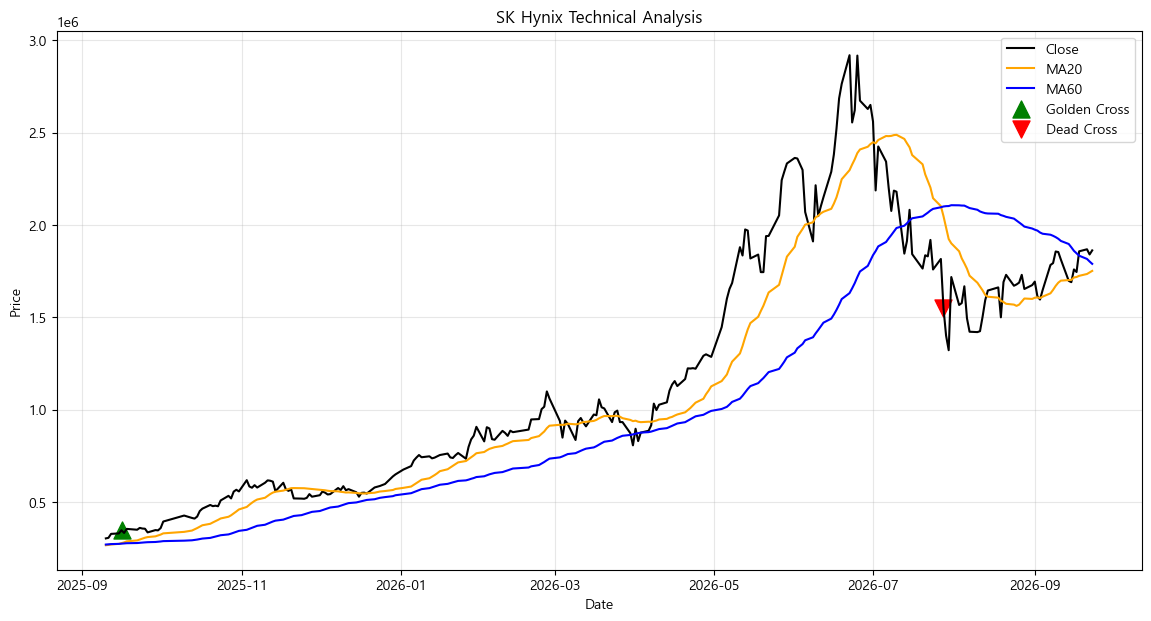

In [51]:
hynix_data = analyze_stock(
    ticker="000660.KS",
    stock_name="SK Hynix"
)

In [ ]:
# 삼성전자
samsung_data = analyze_stock(
    ticker="005930.KS",
    stock_name="Samsung Electronics"
)

In [ ]:
# 엔비디아
nvidia_data = analyze_stock(
    ticker="NVDA",
    stock_name="NVIDIA"
)

In [ ]:
import yfinance as yf
import pandas as pd

stocks = {
    # 한국 반도체·IT
    "SK하이닉스": "000660.KS",
    "삼성전자": "005930.KS",
    "NAVER": "035420.KS",
    "카카오": "035720.KS",

    # 자동차·배터리
    "현대차": "005380.KS",
    "기아": "000270.KS",
    "LG에너지솔루션": "373220.KS",
    "삼성SDI": "006400.KS",

    # 방산·조선·에너지
    "한화에어로스페이스": "012450.KS",
    "현대로템": "064350.KS",
    "HD현대중공업": "329180.KS",
    "SK오션플랜트": "100090.KS",
    "OCI홀딩스": "010060.KS",

    # 바이오
    "삼성바이오로직스": "207940.KS",
    "셀트리온": "068270.KS",

    # 미국 기술주
    "엔비디아": "NVDA",
    "애플": "AAPL",
    "마이크로소프트": "MSFT",
    "테슬라": "TSLA",
    "아마존": "AMZN",
    "구글": "GOOGL"
}

In [ ]:
def scan_stock(stock_name, ticker):
    data = yf.Ticker(ticker).history(period="1y")

    if data.empty or len(data) < 60:
        return None

    # 이동평균선
    data["MA20"] = data["Close"].rolling(20).mean()
    data["MA60"] = data["Close"].rolling(60).mean()

    # 평균 거래량
    data["Volume_MA20"] = data["Volume"].rolling(20).mean()

    # RSI
    change = data["Close"].diff()
    gain = change.clip(lower=0)
    loss = -change.clip(upper=0)

    average_gain = gain.rolling(14).mean()
    average_loss = loss.rolling(14).mean()

    rs = average_gain / average_loss
    data["RSI"] = 100 - (100 / (1 + rs))

    # MACD
    data["EMA12"] = data["Close"].ewm(
        span=12,
        adjust=False
    ).mean()

    data["EMA26"] = data["Close"].ewm(
        span=26,
        adjust=False
    ).mean()

    data["MACD"] = data["EMA12"] - data["EMA26"]

    data["Signal"] = data["MACD"].ewm(
        span=9,
        adjust=False
    ).mean()

    # 골든크로스 및 데드크로스
    data["Golden_Cross"] = (
        (data["MA20"] > data["MA60"]) &
        (data["MA20"].shift(1) <= data["MA60"].shift(1))
    )

    data["Dead_Cross"] = (
        (data["MA20"] < data["MA60"]) &
        (data["MA20"].shift(1) >= data["MA60"].shift(1))
    )

    latest = data.dropna().iloc[-1]

    price = float(latest["Close"])
    ma20 = float(latest["MA20"])
    ma60 = float(latest["MA60"])
    rsi = float(latest["RSI"])
    macd = float(latest["MACD"])
    signal = float(latest["Signal"])

    volume_ratio = float(
        latest["Volume"] / latest["Volume_MA20"]
    )

    # 상승 조건 점수
    score = 0

    if price > ma20:
        score += 1

    if ma20 > ma60:
        score += 1

    if 50 <= rsi < 70:
        score += 1

    if macd > signal:
        score += 1

    if volume_ratio >= 1:
        score += 1

    if score >= 4:
        status = "강한 편"
    elif score >= 2:
        status = "보통"
    else:
        status = "약한 편"

    # 최근 교차 종류 확인
    golden_dates = data.index[data["Golden_Cross"]]
    dead_dates = data.index[data["Dead_Cross"]]

    cross_events = []

    for date in golden_dates:
        cross_events.append((date, "골든크로스"))

    for date in dead_dates:
        cross_events.append((date, "데드크로스"))

    if cross_events:
        latest_cross = max(cross_events, key=lambda x: x[0])
        cross_text = (
            latest_cross[1] +
            " " +
            latest_cross[0].strftime("%Y-%m-%d")
        )
    else:
        cross_text = "최근 1년 교차 없음"

    return {
        "종목": stock_name,
        "티커": ticker,
        "현재가": round(price, 2),
        "MA20": round(ma20, 2),
        "MA60": round(ma60, 2),
        "RSI": round(rsi, 1),
        "거래량비율": round(volume_ratio, 2),
        "상승점수": score,
        "상태": status,
        "최근 교차": cross_text
    }

In [ ]:
stock_results = []

for stock_name, ticker in stocks.items():
    try:
        result = scan_stock(stock_name, ticker)

        if result is not None:
            stock_results.append(result)
            print(f"{stock_name} 분석 완료")

    except Exception as error:
        print(f"{stock_name} 오류: {error}")

ranking_df = pd.DataFrame(stock_results)

ranking_df = ranking_df.sort_values(
    by=["상승점수", "RSI"],
    ascending=[False, False]
).reset_index(drop=True)

display(ranking_df)